# Testowy pipeline oddzielanie + rozpoznawanie symboli muzycznych

In [69]:
import cv2
import numpy as np
import torch
import torch.nn as nn

#### Definicje modeli i definicje funkcji

In [70]:
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(SimpleUNet, self).__init__()
        
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.out = nn.Conv2d(32, out_channels, kernel_size=1)
    
    def forward(self, x):
        enc1 = self.enc1(x)
        x = self.pool1(enc1)
        enc2 = self.enc2(x)
        x = self.pool2(enc2)
        x = self.bottleneck(x)
        x = self.upconv2(x)
        if x.shape[2:] != enc2.shape[2:]:
            x = torch.nn.functional.interpolate(x, size=enc2.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec2(x)
        x = self.upconv1(x)
        if x.shape[2:] != enc1.shape[2:]:
            x = torch.nn.functional.interpolate(x, size=enc1.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec1(x)
        x = self.out(x)
        return x

In [ ]:
def to_white_on_black(gray):
    corners = [gray[0,0], gray[0,-1], gray[-1,0], gray[-1,-1]]
    if int(np.median(corners)) > 127:
        return cv2.bitwise_not(gray)
    return gray.copy()

def remove_staff_lines(img_wob, scale=2, fill_thresh=0.80):
    h, w = img_wob.shape
    big = cv2.resize(img_wob, (w*scale, h*scale), interpolation=cv2.INTER_CUBIC)
    _, binary = cv2.threshold(big, 127, 255, cv2.THRESH_BINARY)
    H, W = binary.shape
    profile = binary.sum(axis=1) / (W * 255)
    line_rows = set()
    for y, fill in enumerate(profile):
        if fill >= fill_thresh:
            for d in range(-scale, scale+1):
                if 0 <= y+d < H:
                    line_rows.add(y+d)

    sorted_rows = sorted(line_rows)
    blocks = []
    if sorted_rows:
        block = [sorted_rows[0]]
        for r in sorted_rows[1:]:
            if r == block[-1] + 1:
                block.append(r)
            else:
                blocks.append(block)
                block = [r]
        blocks.append(block)

    block_thicknesses = [len(b) for b in blocks]
    median_thickness = np.median(block_thicknesses) if block_thicknesses else 1

    filtered_line_rows = set()
    for block in blocks:
        if len(block) <= median_thickness * 1.5:
            filtered_line_rows.update(block)

    result = binary.copy()
    search = scale * 4
    for y in sorted(filtered_line_rows):
        for x in range(W):
            if binary[y, x] == 0:
                continue
            has_symbol = any(
                binary[y2, x] > 0
                for r in range(1, search+1)
                for y2 in [y-r, y+r]
                if 0 <= y2 < H and y2 not in filtered_line_rows
            )
            if not has_symbol:
                result[y, x] = 0

    n_lbl, labels, stats, _ = cv2.connectedComponentsWithStats(result)
    clean = np.zeros_like(result)
    for lbl in range(1, n_lbl):
        if stats[lbl, cv2.CC_STAT_AREA] >= scale*scale*4:
            clean[labels == lbl] = 255
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(3, scale*2)))
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k)
    return cv2.resize(clean, (w, h), interpolation=cv2.INTER_AREA)

def preprocess(img):
    """Zwraca tensor (2, H, W): kanal 0 = z liniami, kanal 1 = bez linii."""
    gray = img
    if gray is None:
        return np.zeros((2, IMG_H, IMG_W), dtype=np.float32)
    wob   = to_white_on_black(gray)
    _, orig_bin = cv2.threshold(wob, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    clean = remove_staff_lines(wob)
    orig  = cv2.resize(orig_bin, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    cln   = cv2.resize(clean,    (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    return np.stack([orig, cln], axis=0)


class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x): return self.relu(x + self.block(x))


class MusicCNN(nn.Module):
    """
    Wejscie: (B, 2, 96, 32)
      kanal 0 = z liniami  -> pozycja na pieciolinii
      kanal 1 = bez linii  -> ksztalt symbolu

    Backbone wspolny, dwie glowice:
      head_type -> typ symbolu (20 klas)
      head_pos  -> rel_position (34 klasy, tylko nuty i accidentals)
      head_dur  -> duration (10 klas)
    """
    def __init__(self, num_types, num_pos, num_dur):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            ResBlock(32), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResBlock(64), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            ResBlock(128), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 2)),
        )
        feat = 256 * 4 * 2

        self.head_type = nn.Sequential(
            nn.Flatten(), nn.Linear(feat, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(256, num_types))

        self.head_pos = nn.Sequential(
            nn.Flatten(), nn.Linear(feat, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(256, num_pos))
        
        self.head_dur = nn.Sequential(        
            nn.Flatten(), nn.Linear(feat, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_dur))

    def forward(self, x):
        f = self.backbone(x)
        return self.head_type(f), self.head_pos(f), self.head_dur(f)
    
class ResNetUNet(nn.Module):
    pass


In [72]:
MODEL_PATH = "SimpleUNet_separator.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(MODEL_PATH, map_location=device)

model_choice   = checkpoint["model_choice"]
# threshold      = checkpoint["threshold"]
# ratio          = checkpoint["ratio"]
threshold = 0.5
ratio = 0.3

if model_choice == "SimpleUNet":
    model = SimpleUNet(in_channels=1, out_channels=1).to(device)
elif model_choice == "ResNetUNet":
    model = ResNetUNet(in_channels=1, out_channels=1).to(device)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classifier_PATH = "music_cnn_v2.pth"
# classifier_PATH = "best_model_.pth"
ckpt = torch.load(classifier_PATH, map_location=DEVICE)


TYPE_CLASSES  = ckpt["TYPE_CLASSES"]
valid_pos     = ckpt["valid_pos"]
DUR_CLASSES   = ckpt["DUR_CLASSES"]
HAS_POSITION  = set(ckpt["HAS_POSITION"])
NUM_TYPES     = ckpt["NUM_TYPES"]
NUM_POS       = ckpt["NUM_POS"]
NUM_DUR       = ckpt["NUM_DUR"]
IMG_W         = ckpt["IMG_W"]
IMG_H         = ckpt["IMG_H"]

classifier = MusicCNN(NUM_TYPES, NUM_POS, NUM_DUR).to(DEVICE)
classifier.load_state_dict(ckpt["model_state_dict"])
classifier.eval()
print(f"✓ Wczytano model")
print(f"  Typy ({NUM_TYPES}): {TYPE_CLASSES}")
print(f"  Pozycje ({NUM_POS}): {valid_pos[0]} .. {valid_pos[-1]}")
print(f"  Duration ({NUM_DUR}): {DUR_CLASSES}")
print(f"  Wymiary: {IMG_H} na {IMG_W}")

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"✓ Wczytano {model_choice} (val F1={checkpoint['val_f1']:.4f})")

✓ Wczytano model
  Typy (33): ['clef_8', 'clef_alto', 'clef_bass', 'clef_tenor', 'clef_treble', 'dot', 'double_sharp', 'flat', 'natural', 'note1', 'note16', 'note2', 'note4', 'note8', 'rest_16th', 'rest_32nd', 'rest_8th', 'rest_half', 'rest_quarter', 'rest_whole', 'sharp', 'time_0', 'time_1', 'time_2', 'time_3', 'time_4', 'time_5', 'time_6', 'time_7', 'time_8', 'time_9', 'time_common', 'time_cut']
  Pozycje (34): -15 .. 19
  Duration (7): ['eighth', 'half', 'no_duration', 'quarter', 'sixteenth', 'thirty_second', 'whole']
  Wymiary: 96 na 32
✓ Wczytano SimpleUNet (val F1=0.8970)


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_19240\2278317338.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)
C

In [ ]:
def predict_separator_columns(image_gray, model, device,
                               patch_size=107,
                               threshold=threshold, ratio=ratio):
    """
    Zwraca binarną tablicę (width,) — True = kolumna separatora.
    image_gray: obraz w skali szarości (uint8, H x W)
    """
    h, w = image_gray.shape

    scale = patch_size / h
    new_w = max(1, int(round(w * scale)))
    resized = cv2.resize(image_gray, (new_w, patch_size))

    x = torch.from_numpy(resized.astype(np.float32) / 255.0)
    x = x.unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, H, W)

    with torch.no_grad():
        output = model(x)                          # (1, 1, H, W)
        pred   = (output > threshold).float()

    pred_np = pred[0, 0].cpu().numpy()             # (H, W)
    col_active = (pred_np.mean(axis=0) > ratio)    # (W,) bool
    return col_active

#### Użycie na własnym obrazie (tu można zmieniać ścieżki)

In [74]:
import matplotlib.pyplot as plt
image_path = "../data/images_pre_gt/134150.png"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

ratio_param = 0.4;
WIDTH_CONST = 1.3

In [75]:
def predict_full_image(image_gray, model, device,
                       patch_size=107, stride=70,
                       threshold=threshold, ratio=ratio_param):
    
    h, w = image_gray.shape
    new_w = max(patch_size, int(WIDTH_CONST * w * patch_size // h))
    img_r = cv2.resize(image_gray, (new_w, patch_size))
    W = new_w

    votes    = np.zeros(W, dtype=np.float32)
    counts   = np.zeros(W, dtype=np.float32)

    starts = list(range(0, W - patch_size, stride))
    if not starts or starts[-1] + patch_size < W:
        starts.append(W - patch_size)
    print(starts)
    for x in starts:
        patch = img_r[:, x:x + patch_size]

        x_t = torch.from_numpy(patch.astype(np.float32) / 255.0)
        x_t = x_t.unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(x_t)
            pred   = torch.sigmoid(output)[0, 0].cpu().numpy()

        col_score = pred.mean(axis=0)
        votes[x:x + patch_size]  += col_score
        counts[x:x + patch_size] += 1.0


    avg_votes = votes / np.maximum(counts, 1)
    separator_cols = avg_votes > ratio

    return separator_cols, avg_votes, img_r


separator_cols, avg_votes, img_r = predict_full_image(img, model, device)

print(f"Szerokość po resize: {img_r.shape[1]} px")
print(f"Znaleziono {separator_cols.sum()} kolumn separatora")

[0, 70, 140, 210, 280, 350, 420, 490, 560, 630, 700, 770, 840, 910, 980, 1050, 1120, 1190, 1193]
Szerokość po resize: 1300 px
Znaleziono 925 kolumn separatora


#### Wizualizacja etapu 1 - oddzielanie nut

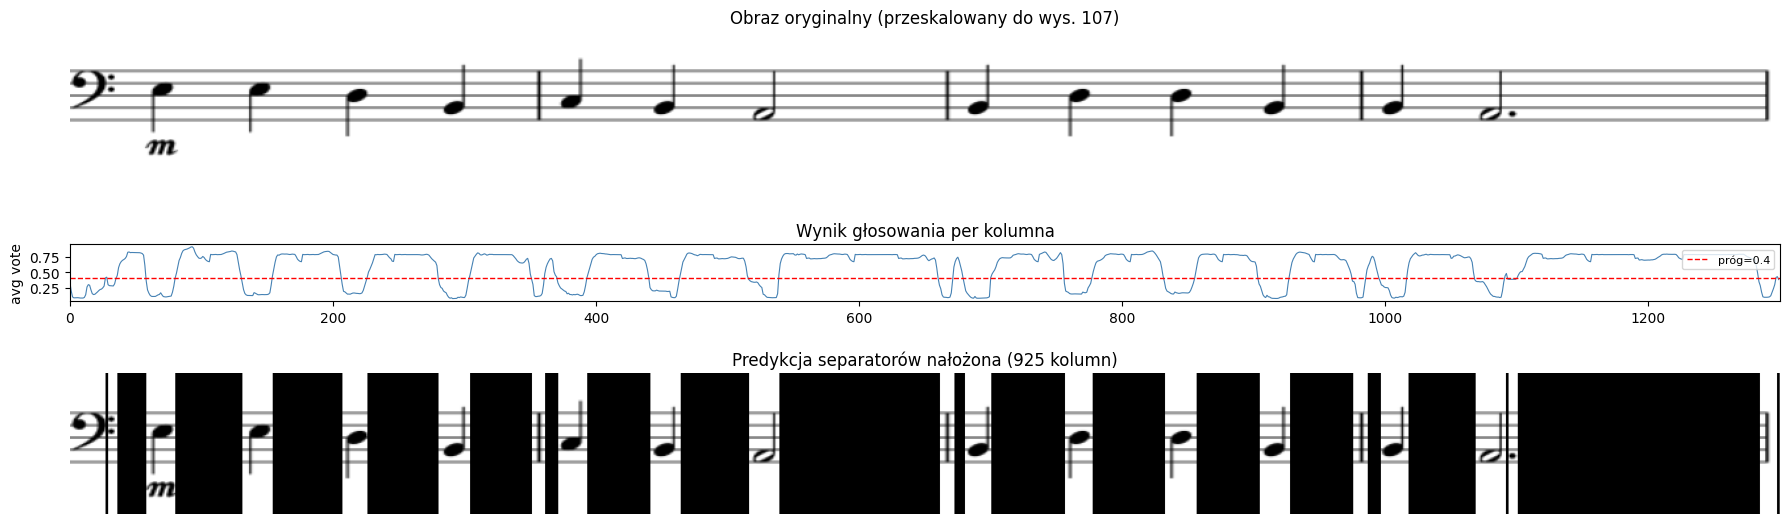

In [76]:
fig, axes = plt.subplots(3, 1, figsize=(18, 6),
                         gridspec_kw={'height_ratios': [4, 1, 4]})

axes[0].imshow(img_r, cmap='gray')
axes[0].set_title("Obraz oryginalny (przeskalowany do wys. 107)")
axes[0].axis('off')

axes[1].plot(avg_votes, linewidth=0.8, color='steelblue')
axes[1].axhline(ratio_param, color='red', linewidth=1, linestyle='--', label=f'próg={ratio_param}')
axes[1].set_xlim(0, len(avg_votes))
axes[1].set_ylabel("avg vote")
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_title("Wynik głosowania per kolumna")

overlay = img_r.copy()
overlay[:, separator_cols] = 0

axes[2].imshow(overlay, cmap='gray')
axes[2].set_title(f"Predykcja separatorów nałożona ({separator_cols.sum()} kolumn)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Znaleziono 19 wycinków (symboli)


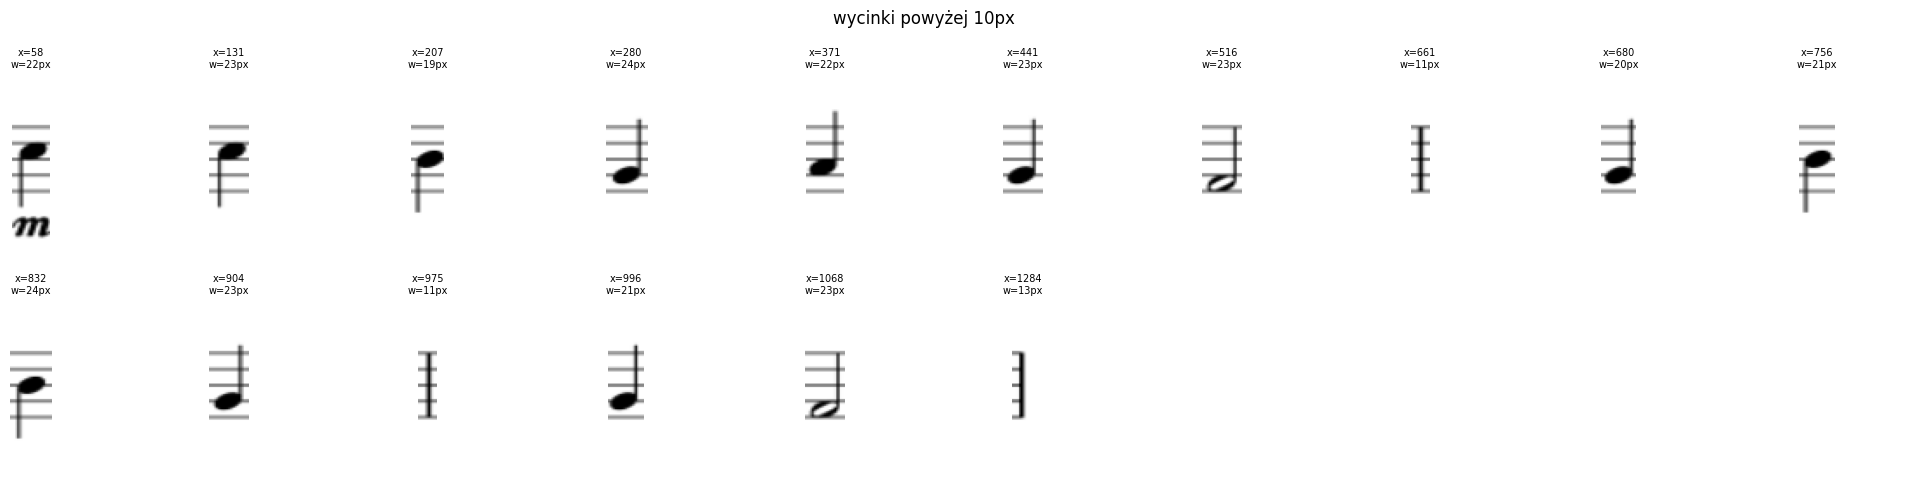

In [77]:
separator_indices = np.where(separator_cols)[0]

gaps = np.where(np.diff(separator_indices) > 1)[0]

seg_starts = separator_indices[gaps] + 1
seg_ends   = separator_indices[gaps + 1]

segments = []
for start, end in zip(seg_starts, seg_ends):
    if end > start:
        crop = img_r[:, start:end]
        segments.append((crop, start, end, end - start))

print(f"Znaleziono {len(segments)} wycinków (symboli)")

segments_sorted = [s for s in segments if s[3] > 10]

n_show = min(20, len(segments_sorted))
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
axes = axes.flatten()

for i in range(n_show):
    crop, start, end, width = segments_sorted[i]
    axes[i].imshow(crop, cmap='gray')
    axes[i].set_title(f"x={start}\nw={width}px", fontsize=7)
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle("wycinki powyżej 10px", fontsize=12)
plt.tight_layout()
plt.show()

#### Etap 2 - rozpoznawanie nut, wizualizacje

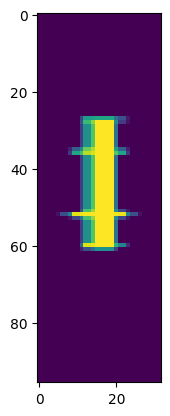

In [78]:
plt.imshow(preprocess(segments_sorted[7][0])[1])

In [79]:
def predict(img):
    t = preprocess(img)
    x = torch.tensor(t, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        ot, op, _ = classifier(x)
    sym = TYPE_CLASSES[ot.argmax(1).item()]
    pos = valid_pos[op.argmax(1).item()] if sym in HAS_POSITION else None
    return sym, pos

In [80]:
for i in range(n_show):
    crop, start, end, width = segments_sorted[i]

    sym, pos = predict(crop)

    axes[i].imshow(crop, cmap='gray')
    label = f"{sym}" + (f"\np={pos}" if pos is not None else "")
    axes[i].set_title(f"x={start} w={width}px\n{label}", fontsize=7)
    axes[i].axis('off')

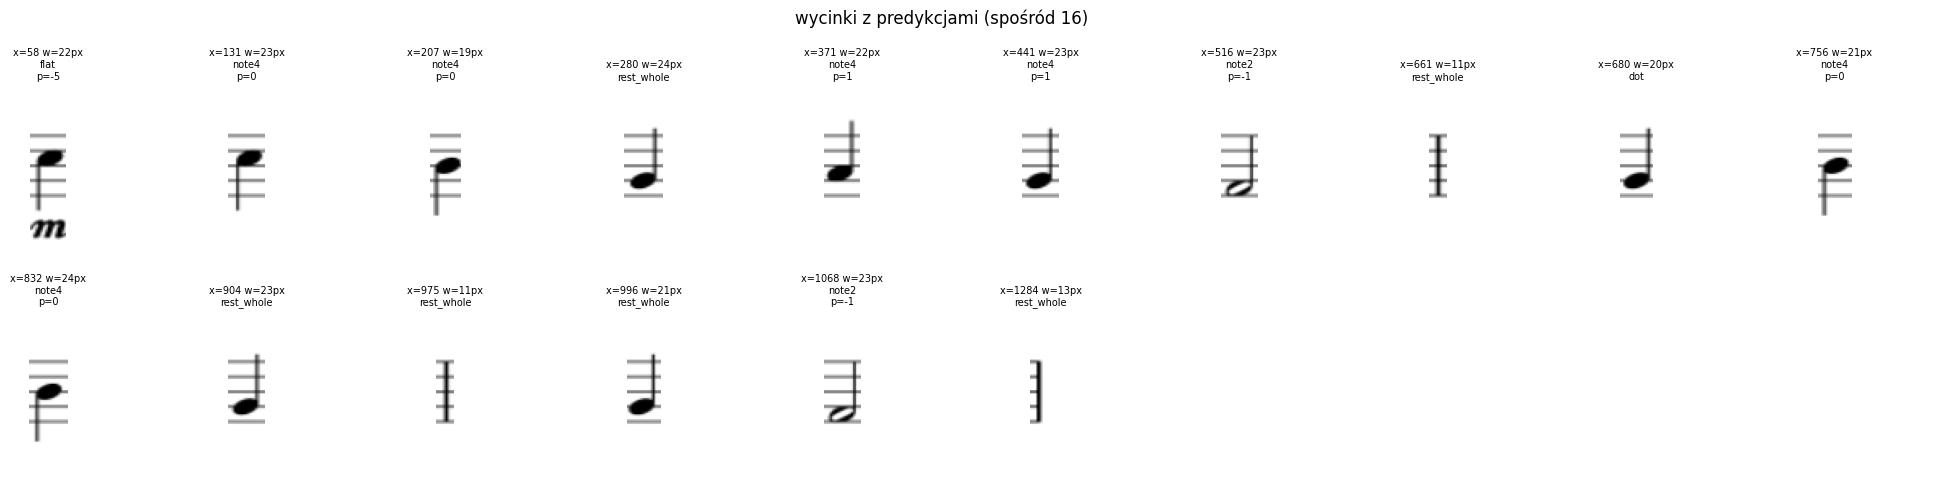

In [81]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
axes = axes.flatten()

for i in range(n_show):
    crop, start, end, width = segments_sorted[i]
    sym, pos = predict(crop)

    axes[i].imshow(crop, cmap='gray')
    label = f"{sym}" + (f"\np={pos}" if pos is not None else "")
    axes[i].set_title(f"x={start} w={width}px\n{label}", fontsize=7)
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle(f"wycinki z predykcjami (spośród {len(segments_sorted)})", fontsize=12)
plt.tight_layout()
plt.show()


#### Ostateczna wizualizacja połączonej metody

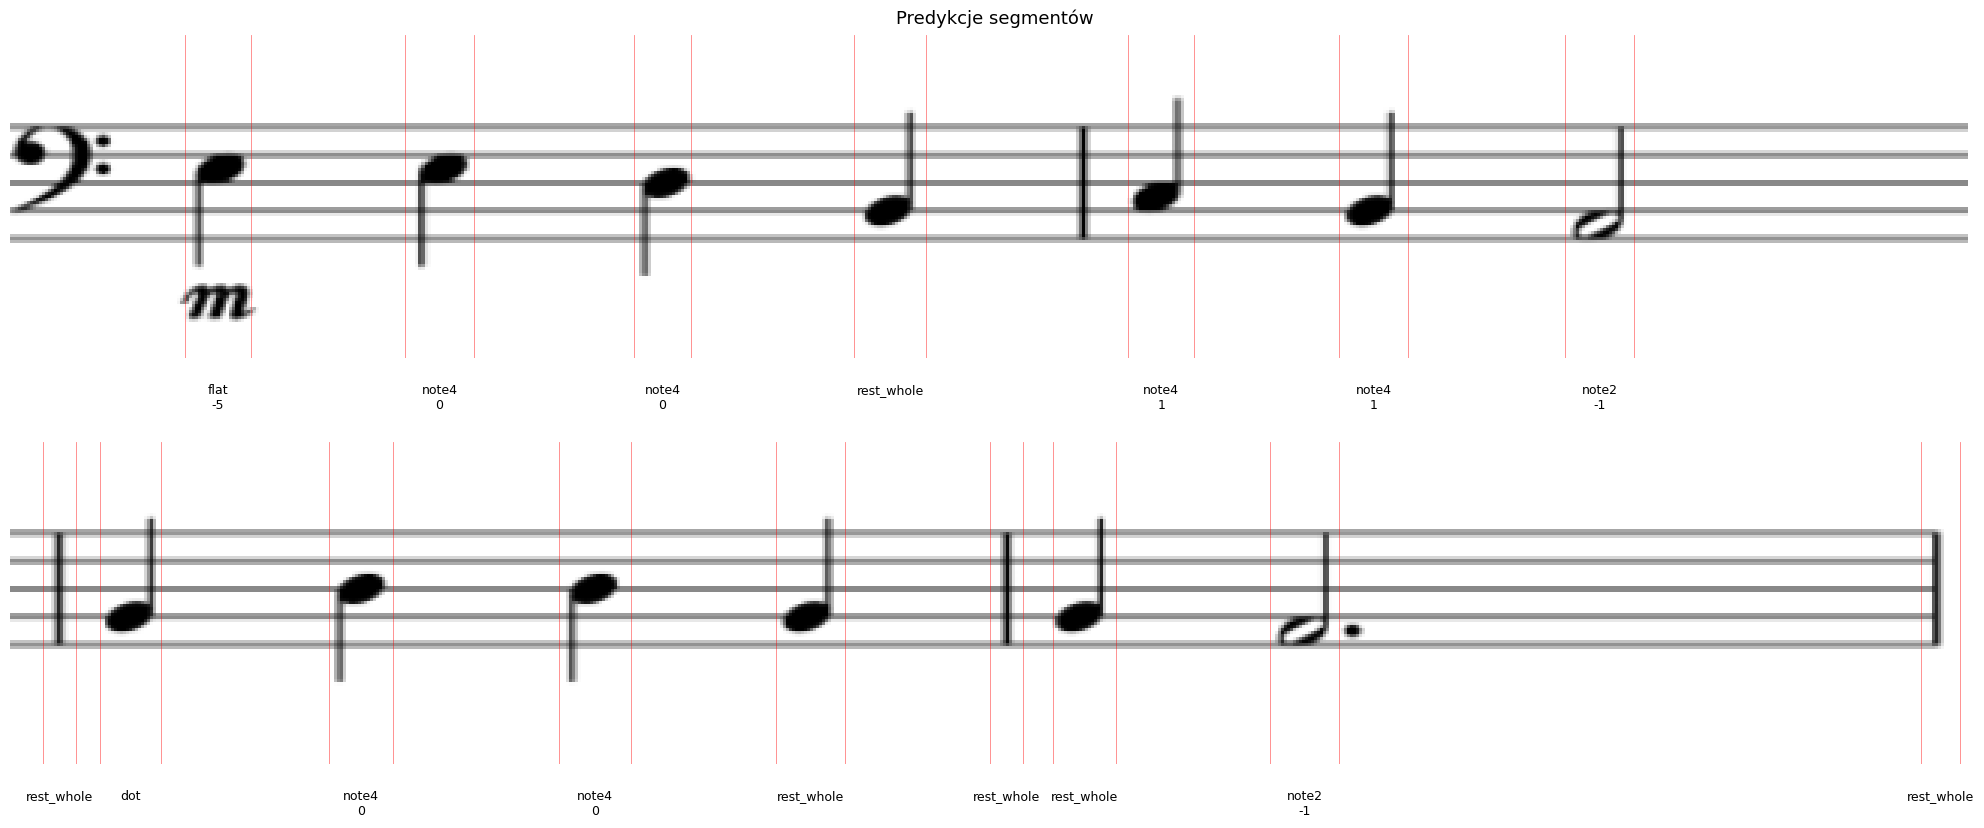

In [82]:
def visualize_predictions(img_gray, segments_sorted, model, device):
    h, w = img_gray.shape
    scale = 107 / h
    new_w = max(107, int(round(WIDTH_CONST * w * scale)))
    img_r = cv2.resize(img_gray, (new_w, 107))

    predictions = []
    for crop, start, end, width in segments_sorted:
        sym, pos = predict(crop)
        label = sym + (f"\n{pos}" if pos is not None else "")
        predictions.append((start, end, width, label))

    mid = new_w // 2
    halves = [
        [(s, e, ww, l) for s, e, ww, l in predictions if e <= mid],
        [(s, e, ww, l) for s, e, ww, l in predictions if s >= mid],
    ]
    imgs = [img_r[:, :mid], img_r[:, mid:]]
    offsets = [0, mid]

    fig, axes = plt.subplots(2, 1, figsize=(20, 8))

    for row, (ax, half_img, preds, offset) in enumerate(zip(axes, imgs, halves, offsets)):
        ax.imshow(half_img, cmap='gray')
        ax.set_xlim(0, half_img.shape[1])
        ax.axis('off')

        for start, end, width, label in preds:
            cx = (start + end) / 2 - offset
            ax.axvline(x=start - offset, color='red', linewidth=0.6, alpha=0.5)
            ax.axvline(x=end   - offset, color='red', linewidth=0.6, alpha=0.5)
            ax.text(
                cx, 115,
                label,
                ha='center', va='top',
                fontsize=9,
                clip_on=False,
            )

    plt.tight_layout(h_pad=4)
    plt.suptitle("Predykcje segmentów", fontsize=13, y=1.01)
    plt.show()

visualize_predictions(img, segments_sorted, model, device)